In [16]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Linear Regression
## How does it work?
- Draw a line that goes through the data in the middle of the point
## Gradient Descent?
- Optimization of algo to get the min of the function
- Linear Regression to find minimum error
- Gradient Descebt optimizer function => best slope going through the data
- Error getting lower and lower
 *Y* = m * *X* + p

# Part 1 Gathering Data
Generate data with numpy

In [17]:
m = 2
p = 0.5
x = np.linspace(0, 4, 100)
y = m * x + p + np.random.randn(*x.shape) + 0.25

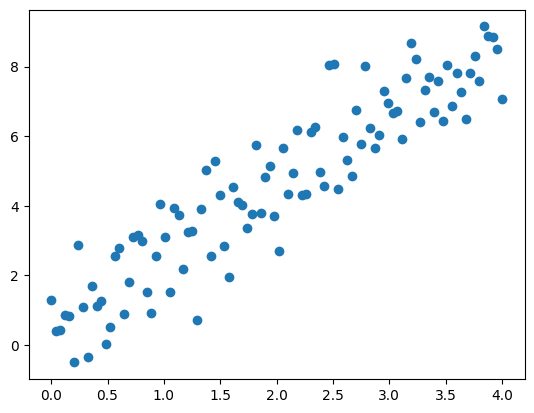

In [18]:
plt.scatter(x,y)

# Part 2 tf.Variable

# Part 3 Adding the Operations

In [19]:
class Model:
    def __init__(self):
        self.weight = tf.Variable(10.0)
        self.bias = tf.Variable(10.0)

    def __call__(self, x):
        return self.weight * x + self.bias
   # model = Model()
    # model(5.0)
    # self.weight.assign_sub(15.0)
        

# Part 4 Loss Fonction

In [20]:
def calculate_loss(y_actual, y_output):
    return tf.reduce_mean(tf.square(y_actual - y_output))    

# Part 5 Training
- Loop

In [21]:
def train(model, x, y, learning_rate):
    with tf.GradientTape() as gt:
        y_output = model(x)
        loss = calculate_loss(y, y_output)

    new_weight, new_bias = gt.gradient(loss, [model.weight, model.bias])
    model.weight.assign_sub(new_weight * learning_rate)
    model.bias.assign_sub(new_bias * learning_rate)

In [22]:
model = Model()
epochs = 100
learning_rate = 0.15

for epoch in range(epochs):
    y_output = model(x)
    loss = calculate_loss(y, y_output)
    print(f"Epoch: {epoch}, loss: {loss.numpy()}")
    train(model, x, y, learning_rate)

Epoch: 0, loss: 732.58642578125
Epoch: 1, loss: 520.4096069335938
Epoch: 2, loss: 369.9660949707031
Epoch: 3, loss: 263.26849365234375
Epoch: 4, loss: 187.57388305664062
Epoch: 5, loss: 133.85414123535156
Epoch: 6, loss: 95.71268463134766
Epoch: 7, loss: 68.61714172363281
Epoch: 8, loss: 49.35564422607422
Epoch: 9, loss: 35.65195846557617
Epoch: 10, loss: 25.892671585083008
Epoch: 11, loss: 18.934011459350586
Epoch: 12, loss: 13.964958190917969
Epoch: 13, loss: 10.410305976867676
Epoch: 14, loss: 7.86198616027832
Epoch: 15, loss: 6.030378341674805
Epoch: 16, loss: 4.709838390350342
Epoch: 17, loss: 3.7542712688446045
Epoch: 18, loss: 3.059812307357788
Epoch: 19, loss: 2.5525636672973633
Epoch: 20, loss: 2.1798899173736572
Epoch: 21, loss: 1.9042569398880005
Epoch: 22, loss: 1.6988568305969238
Epoch: 23, loss: 1.544510006904602
Epoch: 24, loss: 1.427463412284851
Epoch: 25, loss: 1.3378286361694336
Epoch: 26, loss: 1.2684749364852905
Epoch: 27, loss: 1.2142406702041626
Epoch: 28, loss: 1

In [23]:
print(model.weight.numpy())
print(model.bias.numpy())

2.0008416
0.60997176


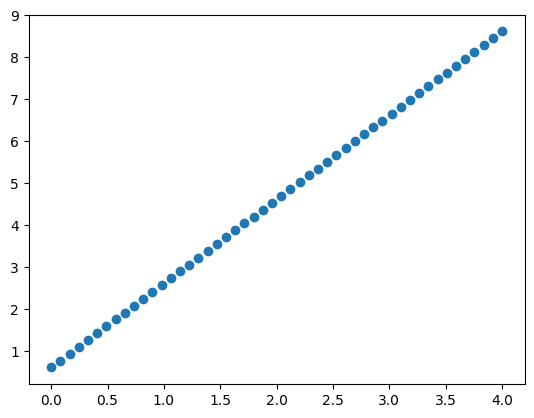

In [24]:
new_x = np.linspace(0, 4, 50)
new_y = model.weight.numpy() * new_x + model.bias.numpy()
plt.scatter(new_x, new_y)